In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [131]:
df=pd.read_csv('loan_prediction.csv')
df.drop('Loan_ID', axis=1,inplace=True)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [132]:
df_categorical=['Gender','Married','Dependents','Education','Self_Employed','Property_Area','Loan_Amount_Term','Credit_History']
df_numeric=['ApplicantIncome','CoapplicantIncome','LoanAmount']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Dependents         599 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      582 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 62.4+ KB


In [133]:
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_9988\467076715.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_9988\467076715.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

We can fill in the missing values of the loan amount column with the median value. The median is an appropriate measure to fill in missing values when dealing with skewed distributions or when outliers are present in the data;


We can fill in the missing values of the loan amount term column with the mode value of the column. Since the term of the loan amount is a discrete value, the mode is an appropriate metric to use;


We can fill in the missing values of the credit history column with the mode value. Since credit history is a binary variable (0 or 1), the mode represents the most common value and is an appropriate choice for filling in missing values.



In [134]:
# Fill missing values in LoanAmount with the median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Fill missing values in Loan_Amount_Term with the mode
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# Fill missing values in Credit_History with the mode
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_9988\1445627372.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_9988\1445627372.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [135]:
map={
    'Y':1
    ,'N':0
}
df['Loan_Status_bin']=df['Loan_Status'].map(map)
df['Loan_Status_bin'].head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status_bin, dtype: int64

In [136]:
df_cat=pd.get_dummies(data=df, columns=df_categorical)
df_cat.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Status,Loan_Status_bin,Gender_Female,Gender_Male,Married_No,Married_Yes,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Amount_Term_12.0,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0,Credit_History_0.0,Credit_History_1.0
0,5849,0.0,128.0,Y,1,False,True,True,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
1,4583,1508.0,128.0,N,0,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
2,3000,0.0,66.0,Y,1,False,True,False,True,True,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
3,2583,2358.0,120.0,Y,1,False,True,False,True,True,False,False,False,False,True,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True
4,6000,0.0,141.0,Y,1,False,True,True,False,True,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True


In [137]:
df['Credit_History'].value_counts()

Credit_History
1.0    525
0.0     89
Name: count, dtype: int64

In [138]:
df[df_numeric].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount
count,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443
std,6109.041673,2926.248369,84.107233
min,150.000000,0.000000,9.000000
25%,2877.500000,0.000000,100.250000
50%,3812.500000,1188.500000,128.000000
75%,5795.000000,2297.250000,164.750000
max,81000.000000,41667.000000,700.000000


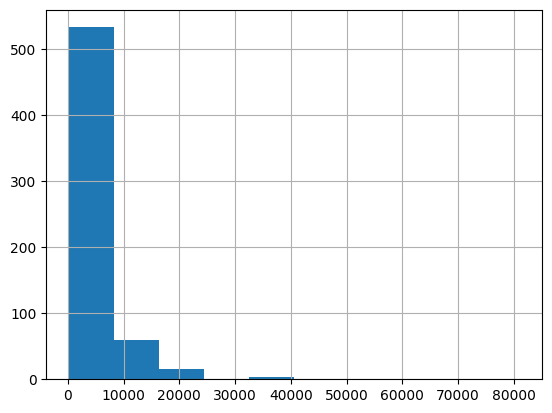

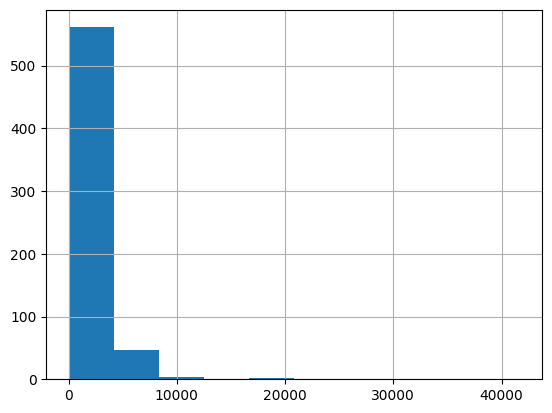

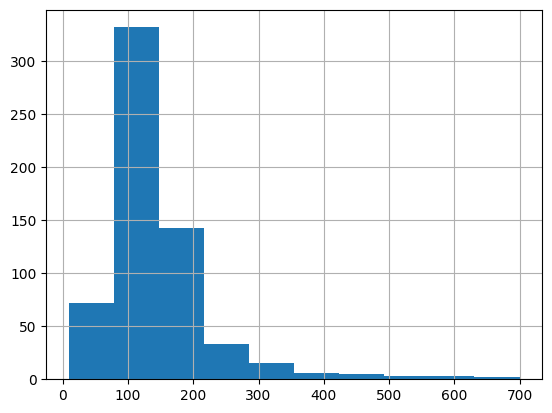

In [139]:
for feature in df_numeric:
    df[feature].hist()
    plt.show()

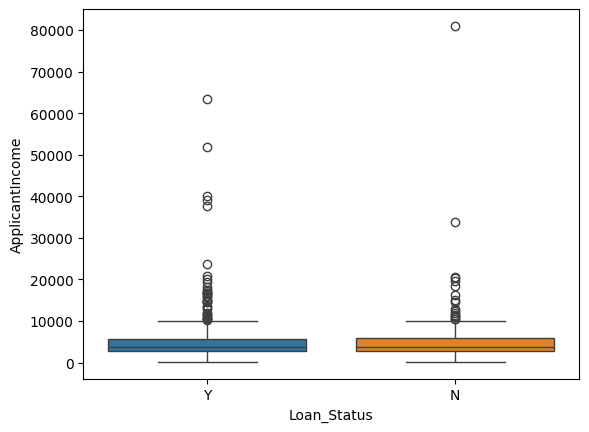

In [140]:
sns.boxplot(data=df, x='Loan_Status', 
                    y='ApplicantIncome',
                    hue="Loan_Status", 
                    )
plt.show()

In [141]:
Q1 = df['ApplicantIncome'].quantile(0.25)
Q3 = df['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['ApplicantIncome'] >= lower_bound) & (df['ApplicantIncome'] <= upper_bound)]

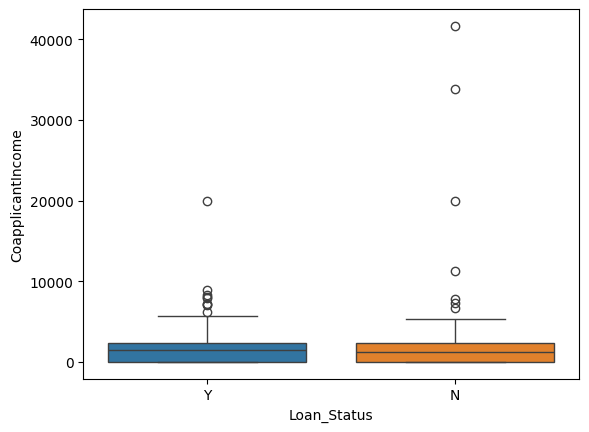

In [142]:
sns.boxplot(df, x='Loan_Status', 
            y='CoapplicantIncome',
            hue="Loan_Status")
plt.show()

In [143]:
Q1 = df['CoapplicantIncome'].quantile(0.25)
Q3 = df['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['CoapplicantIncome'] >= lower_bound) & (df['CoapplicantIncome'] <= upper_bound)]

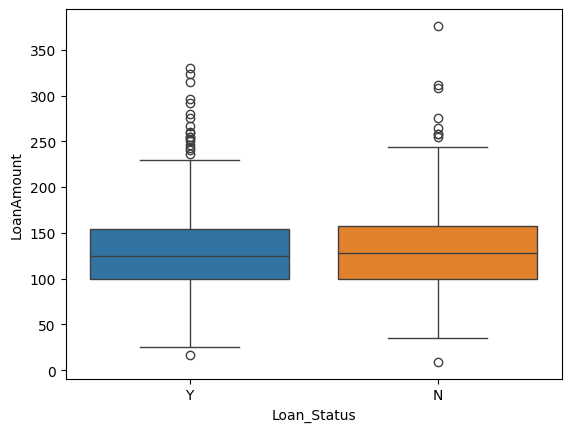

In [144]:
sns.boxplot(df, x='Loan_Status', 
                         y='LoanAmount', 
                         hue="Loan_Status")
plt.show()

In [145]:
data=df_cat.dropna()
X=data.drop(columns=['Loan_Status','Loan_Status_bin'], axis=1).values
y=data['Loan_Status_bin'].values
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, stratify=y, random_state=42)

In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lr=LogisticRegression()
scaler=StandardScaler()

pipeline=make_pipeline(scaler,lr)
pipeline.fit(X_train,y_train)
print(pipeline.score(X_test,y_test))

0.8636363636363636


In [147]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5, min_samples_split=0.2, min_samples_leaf=0.06)
dt.fit(X_train,y_train)
print(dt.score(X_test,y_test))

0.8571428571428571


In [148]:
from sklearn.model_selection import GridSearchCV
dt = DecisionTreeClassifier(random_state=42)

param_grid={
    'max_depth': [1, 3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 0.1, 0.2],
    'min_samples_leaf': [1, 2, 5, 0.05, 0.1]
}

grid=GridSearchCV(dt,param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train,y_train)
print("Найкращі параметри:", grid.best_params_)
print("Точність на train:", grid.best_score_)
print("Точність на test:", grid.score(X_test, y_test))

Найкращі параметри: {'max_depth': 1, 'min_samples_leaf': 1, 'min_samples_split': 2}
Точність на train: 0.7934782608695652
Точність на test: 0.8571428571428571


In [149]:
lr = LogisticRegression(max_iter=500, random_state=42)

param_grid ={
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__penalty': ['l2']
}

pipeline = make_pipeline(StandardScaler(), lr)
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Найкращі параметри:", grid.best_params_)
print("Точність на train:", grid.best_score_)
print("Точність на test:", grid.score(X_test, y_test))

Найкращі параметри: {'logisticregression__C': 0.01, 'logisticregression__penalty': 'l2'}
Точність на train: 0.7913043478260869
Точність на test: 0.8636363636363636
